# Training a Tissue Segmentor from Slide + Annotation Store Pairs


## About this notebook

This notebook demonstrates PR3 training support in `tiatoolbox.models.training`:
- on-the-fly patch extraction from a slide (`ndpi-1`),
- training targets generated from a paired TIAToolbox annotation store (`.db`),
- segmentation training with `SlideAnnotationPatchDataset`,
- whole-slide inference using `SemanticSegmentor` with the trained model.


## About this demo

Workflow used here:
1. Download the remote sample WSI `ndpi-1`.
2. Build a tissue mask using `WSIReader.tissue_mask()` at 2 mpp.
3. Convert tissue contours from mask coordinates to **baseline** WSI coordinates and save them into a `SQLiteStore`.
4. Train a lightweight segmentation model to reproduce this tissue mask.
5. Run WSI inference with `SemanticSegmentor`.
6. Show predicted and reference masks side-by-side, and report Dice / IoU.

To keep runtime practical, we train on a balanced subset of extracted patches.


## Optional: Colab setup


In [ ]:
%%bash
python -m pip install --quiet --upgrade pip
python -m pip install --quiet tiatoolbox


If you are using Colab and ran the install cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [1]:
from __future__ import annotations

import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import zarr
from shapely.geometry import Polygon
from torch import nn
from torch.utils.data import DataLoader, Subset

from tiatoolbox.annotation import Annotation, SQLiteStore
from tiatoolbox.data import _fetch_remote_sample
from tiatoolbox.models.engine.io_config import IOSegmentorConfig
from tiatoolbox.models.engine.semantic_segmentor import SemanticSegmentor
from tiatoolbox.models.models_abc import ModelABC
from tiatoolbox.models.training import (
    MaskTargetBuilder,
    SegmentationTask,
    SlideAnnotationPatchDataset,
    Trainer,
    TrainerConfig,
)
from tiatoolbox.wsicore.wsireader import WSIReader

rng = np.random.default_rng(7)
torch.manual_seed(7)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


|2026-03-13|16:43:19.197| [WARNING] /home/mark-eastwood/miniforge3/envs/comfyui/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Using device: cuda


## Download the remote sample WSI (`ndpi-1`)


In [2]:
work_dir = Path("tmp/slide_annotation_training_demo")
work_dir.mkdir(parents=True, exist_ok=True)

wsi_path = _fetch_remote_sample("ndpi-1", tmp_path=work_dir)
reader = WSIReader.open(wsi_path)

print(f"WSI path: {wsi_path}")
print(f"WSI baseline dimensions (W, H): {tuple(reader.info.slide_dimensions)}")


WSI path: tmp/slide_annotation_training_demo/sample_wsis/CMU-1.ndpi
WSI baseline dimensions (W, H): (51200, 38144)


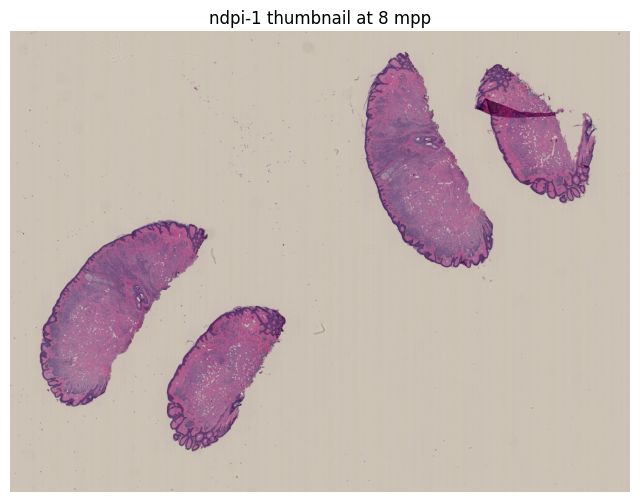

In [3]:
preview = reader.slide_thumbnail(resolution=8.0, units="mpp")

plt.figure(figsize=(8, 8))
plt.imshow(preview)
plt.title("ndpi-1 thumbnail at 8 mpp")
plt.axis("off")
plt.show()


## Build tissue annotations from `tissue_mask()`

Important: annotation geometries must be stored in **baseline coordinates**.


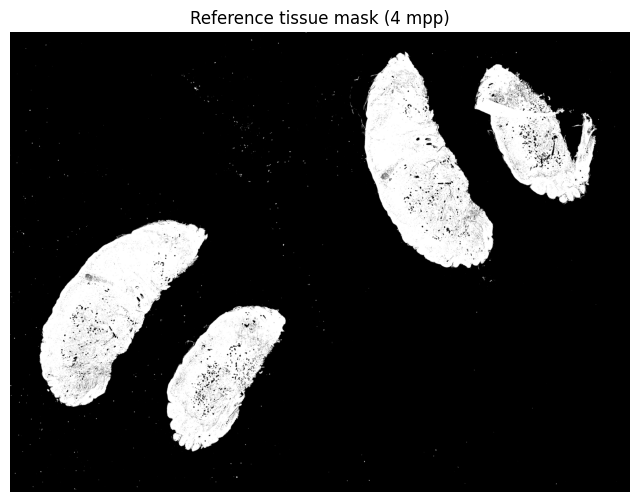

In [4]:
mask_resolution = 4.0
mask_units = "mpp"

mask_reader = reader.tissue_mask(method="otsu", resolution=mask_resolution, units=mask_units)
actual_mask = (mask_reader.img > 0).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(actual_mask, cmap="gray")
plt.title("Reference tissue mask (4 mpp)")
plt.axis("off")
plt.show()


In [5]:
store_path = work_dir / "tissue_annotations.db"
if store_path.exists():
    store_path.unlink()

store = SQLiteStore(store_path)

mask_h, mask_w = actual_mask.shape
baseline_w, baseline_h = reader.info.slide_dimensions
scale_x = float(baseline_w) / float(mask_w)
scale_y = float(baseline_h) / float(mask_h)

contours, _ = cv2.findContours(
    (actual_mask * 255).astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)

num_polygons = 0
for contour_index, contour in enumerate(contours):
    if contour.shape[0] < 3:
        continue

    xy = contour[:, 0, :].astype(np.float64)
    xy[:, 0] *= scale_x
    xy[:, 1] *= scale_y

    polygon = Polygon(xy).buffer(0)
    if polygon.is_empty:
        continue

    polygons = [polygon] if polygon.geom_type == "Polygon" else list(polygon.geoms)
    for poly_index, poly in enumerate(polygons):
        if poly.is_empty or poly.area <= 0:
            continue
        store.append(
            Annotation(poly, properties={"class": "tissue"}),
            key=f"tissue_{contour_index}_{poly_index}",
        )
        num_polygons += 1

print(f"Saved {num_polygons} baseline-coordinate polygons to {store_path}")


Saved 1081 baseline-coordinate polygons to tmp/slide_annotation_training_demo/tissue_annotations.db


## Build slide-level training dataset (on-the-fly patch extraction)


In [6]:
target_builder = MaskTargetBuilder(
    class_mapping={"tissue": 1},
    class_property="class",
    default_label=0,
)

dataset = SlideAnnotationPatchDataset(
    slide_inputs=[wsi_path],
    annotation_stores=[store_path],
    target_builder=target_builder,
    patch_size=(256, 256),
    stride=(256, 256),
    resolution=2.0,
    units="mpp",
    within_bound=True,
)

print(f"Total generated patches: {len(dataset)}")


Total generated patches: 1485


## Create a balanced train/validation split

We create a binary patch-level presence label from the reference mask and sample a balanced subset.


In [7]:
coords = dataset.sample_bounds

# dataset coords are at 2 mpp, while `actual_mask` is at 4 mpp
mask_h, mask_w = actual_mask.shape
slide_w_2mpp, slide_h_2mpp = reader.slide_dimensions(resolution=2.0, units="mpp")
coord_to_mask_x = float(mask_w) / float(slide_w_2mpp)
coord_to_mask_y = float(mask_h) / float(slide_h_2mpp)

presence = []
for x0, y0, x1, y1 in coords:
    x0 = int(np.floor(float(x0) * coord_to_mask_x))
    y0 = int(np.floor(float(y0) * coord_to_mask_y))
    x1 = int(np.ceil(float(x1) * coord_to_mask_x))
    y1 = int(np.ceil(float(y1) * coord_to_mask_y))

    x0 = max(0, min(x0, mask_w))
    y0 = max(0, min(y0, mask_h))
    x1 = max(0, min(x1, mask_w))
    y1 = max(0, min(y1, mask_h))

    patch_mask = actual_mask[y0:y1, x0:x1]
    patch_ratio = float(patch_mask.mean()) if patch_mask.size > 0 else 0.0
    presence.append(int(patch_ratio > 0.05))

presence = np.asarray(presence, dtype=np.int64)
pos_indices = np.where(presence == 1)[0]
neg_indices = np.where(presence == 0)[0]

if len(pos_indices) == 0 or len(neg_indices) == 0:
    raise RuntimeError("Could not form a balanced split from this slide.")

max_per_class = min(len(pos_indices), len(neg_indices), 300)
selected_pos = rng.choice(pos_indices, size=max_per_class, replace=False)
selected_neg = rng.choice(neg_indices, size=max_per_class, replace=False)
selected_indices = np.concatenate([selected_pos, selected_neg])
rng.shuffle(selected_indices)

val_size = max(1, int(0.2 * len(selected_indices)))
val_indices = selected_indices[:val_size]
train_indices = selected_indices[val_size:]

train_subset = Subset(dataset, train_indices.tolist())
val_subset = Subset(dataset, val_indices.tolist())

print(f"Selected patches: {len(selected_indices)}")
print(f"Train / val: {len(train_subset)} / {len(val_subset)}")
print(f"Positive / negative in selected set: {(presence[selected_indices] == 1).sum()} / {(presence[selected_indices] == 0).sum()}")


Selected patches: 600
Train / val: 480 / 120
Positive / negative in selected set: 300 / 300


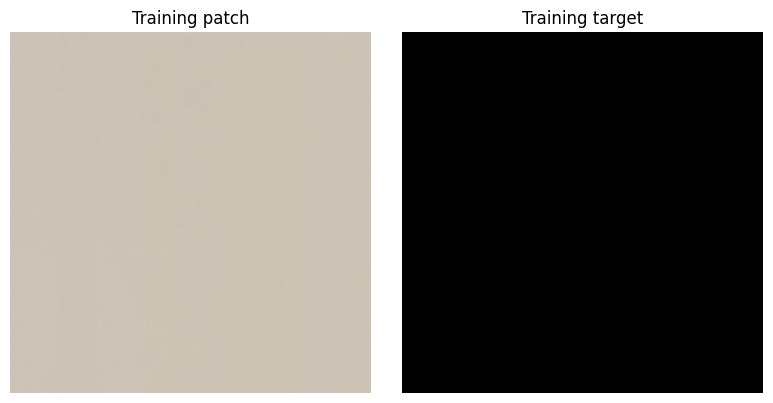

In [8]:
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False, num_workers=0)

sample = dataset[int(train_indices[0])]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample["image"].permute(1, 2, 0).numpy())
axes[0].set_title("Training patch")
axes[0].axis("off")

axes[1].imshow(sample["target"].numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Training target")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Define a lightweight segmentation model (training + engine inference compatible)


In [9]:
class TinyTissueSegModel(ModelABC):
    def __init__(self, num_classes: int = 2) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, num_classes, kernel_size=1),
        )
        self.class_dict = {0: "background", 1: "tissue"}

    def forward(self, imgs: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(imgs))

    @staticmethod
    def preproc(image: np.ndarray) -> np.ndarray:
        image = image.astype(np.float32)
        if image.max() > 1:
            image = image / 255.0
        return image

    @staticmethod
    def postproc(image: np.ndarray) -> np.ndarray:
        return np.argmax(image, axis=-1).astype(np.uint8)

    @staticmethod
    def infer_batch(
        model: nn.Module,
        batch_data: np.ndarray | torch.Tensor,
        *,
        device: str,
    ) -> np.ndarray:
        model.eval()

        imgs = batch_data if isinstance(batch_data, torch.Tensor) else torch.as_tensor(batch_data)
        imgs = imgs.to(device).float()

        if imgs.ndim != 4:
            raise ValueError("Expected a 4D batch tensor.")
        if imgs.shape[-1] in {1, 3, 4}:
            imgs = imgs.permute(0, 3, 1, 2).contiguous()

        with torch.inference_mode():
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)

        return probs.permute(0, 2, 3, 1).cpu().numpy()


## Train the model


In [10]:
model = TinyTissueSegModel(num_classes=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_output_dir = work_dir / "trainer_output"
if train_output_dir.exists():
    shutil.rmtree(train_output_dir)

trainer = Trainer(
    model=model,
    task=SegmentationTask(loss="cross_entropy"),
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=40,
        device=device,
        amp=True,
        seed=7,
        output_dir=train_output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)

history = trainer.fit()
#history


|2026-03-13|16:43:28.431| [WARNING] /media/mark-eastwood/Work/tiatoolbox/tiatoolbox/models/training/trainer.py:150: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.grad_scaler = GradScaler(enabled=self.use_amp)

|2026-03-13|16:43:28.522| [WARNING] /media/mark-eastwood/Work/tiatoolbox/tiatoolbox/models/training/trainer.py:266: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):



|2026-03-13|16:43:34.456| [INFO] Epoch 1/40 | monitor `val_loss`=0.250326 | best=0.250326
|2026-03-13|16:43:39.788| [INFO] Epoch 2/40 | monitor `val_loss`=0.043519 | best=0.043519
|2026-03-13|16:43:45.285| [INFO] Epoch 3/40 | monitor `val_loss`=0.044979 | best=0.043519
|2026-03-13|16:43:50.411| [INFO] Epoch 4/40 | monitor `val_loss`=0.075357 | best=0.043519
|2026-03-13|16:43:55.400| [INFO] Epoch 5/40 | monitor `val_loss`=0.041755 | best=0.041755
|2026-03-13|16:44:00.655| [INFO] Epoch 6/40 | monitor `val_loss`=0.040596 | best=0.040596
|2026-03-13|16:44:06.255| [INFO] Epoch 7/40 | monitor `val_loss`=0.053555 | best=0.040596
|2026-03-13|16:44:11.672| [INFO] Epoch 8/40 | monitor `val_loss`=0.040410 | best=0.040410
|2026-03-13|16:44:16.615| [INFO] Epoch 9/40 | monitor `val_loss`=0.037533 | best=0.037533
|2026-03-13|16:44:21.651| [INFO] Epoch 10/40 | monitor `val_loss`=0.040460 | best=0.037533
|2026-03-13|16:44:27.699| [INFO] Epoch 11/40 | monitor `val_loss`=0.037060 | best=0.037060
|2026-03

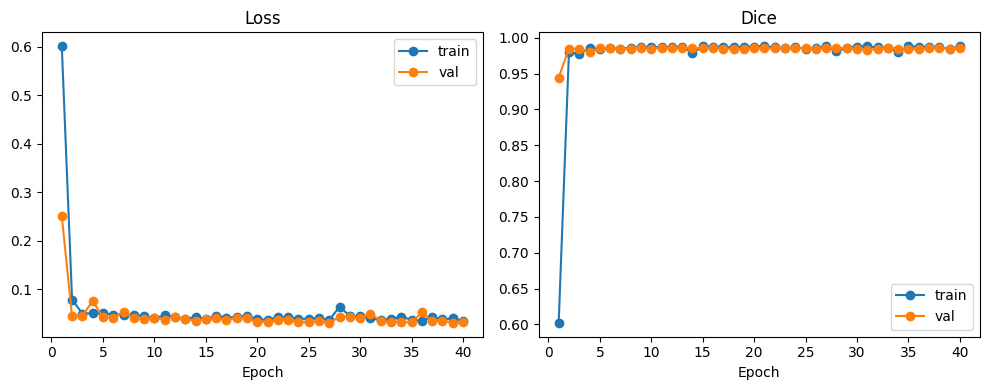

In [11]:
epochs = [int(row["epoch"]) for row in history]
train_losses = [row["train_loss"] for row in history]
val_losses = [row.get("val_loss", np.nan) for row in history]
train_dice = [row.get("train_dice", np.nan) for row in history]
val_dice = [row.get("val_dice", np.nan) for row in history]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, train_losses, marker="o", label="train")
axes[0].plot(epochs, val_losses, marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, train_dice, marker="o", label="train")
axes[1].plot(epochs, val_dice, marker="o", label="val")
axes[1].set_title("Dice")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## Run whole-slide inference with `SemanticSegmentor`


In [12]:
best_weights = train_output_dir / "best_model_weights.pth"
inference_model = TinyTissueSegModel(num_classes=2)
inference_model.load_state_dict(torch.load(best_weights, map_location="cpu"))

segmentor = SemanticSegmentor(
    model=inference_model,
    batch_size=8,
    num_workers=0,
    device=device,
)

ioconfig = IOSegmentorConfig(
    input_resolutions=[{"units": "mpp", "resolution": 2.0}],
    output_resolutions=[{"units": "mpp", "resolution": 2.0}],
    patch_input_shape=(256, 256),
    patch_output_shape=(256, 256),
    stride_shape=(256, 256),
)

inference_output = segmentor.run(
    images=[wsi_path],
    patch_mode=False,
    auto_get_mask=False,
    ioconfig=ioconfig,
    save_dir=work_dir / "semantic_segmentor_output",
    output_type="zarr",
    return_probabilities=True,
    overwrite=True,
    device=device,
)

inference_output


|2026-03-13|16:46:58.904| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


|2026-03-13|16:46:58.905| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-03-13|16:47:15.061| [INFO] Output file saved at tmp/slide_annotation_training_demo/semantic_segmentor_output/CMU-1.zarr.


{PosixPath('tmp/slide_annotation_training_demo/sample_wsis/CMU-1.ndpi'): PosixPath('tmp/slide_annotation_training_demo/semantic_segmentor_output/CMU-1.zarr')}

## Compare predicted and reference masks


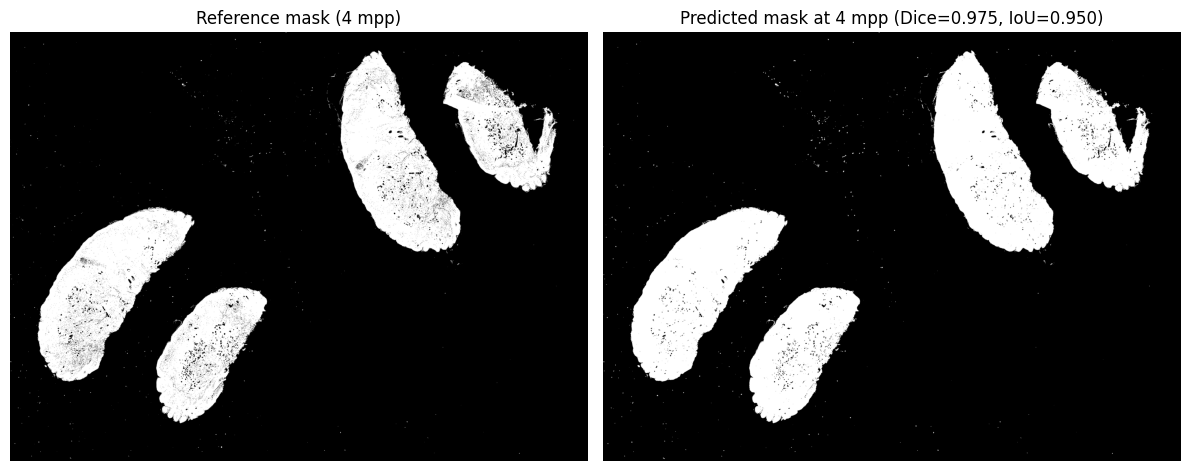

Dice (4 mpp): 0.9746
IoU  (4 mpp): 0.9504


In [13]:
prediction_zarr_path = Path(inference_output[Path(wsi_path)])
prediction_store = zarr.open(prediction_zarr_path, mode="r")
predicted_mask_2mpp = np.asarray(prediction_store["predictions"]).astype(np.uint8)

# Crop prediction to the true 2 mpp slide size
slide_w_2mpp, slide_h_2mpp = reader.slide_dimensions(resolution=2.0, units="mpp")
predicted_mask_2mpp = predicted_mask_2mpp[:slide_h_2mpp, :slide_w_2mpp]

# Compare at 4 mpp: resize prediction from 2 mpp -> 4 mpp grid
reference_mask_4mpp = actual_mask.astype(np.uint8)
predicted_mask_4mpp = cv2.resize(
    predicted_mask_2mpp,
    (reference_mask_4mpp.shape[1], reference_mask_4mpp.shape[0]),
    interpolation=cv2.INTER_NEAREST,
).astype(np.uint8)

h = min(predicted_mask_4mpp.shape[0], reference_mask_4mpp.shape[0])
w = min(predicted_mask_4mpp.shape[1], reference_mask_4mpp.shape[1])
predicted_mask = predicted_mask_4mpp[:h, :w]
reference_mask = reference_mask_4mpp[:h, :w]

pred_bool = predicted_mask > 0
ref_bool = reference_mask > 0
intersection = np.logical_and(pred_bool, ref_bool).sum()
pred_area = pred_bool.sum()
ref_area = ref_bool.sum()
union = np.logical_or(pred_bool, ref_bool).sum()
dice = (2.0 * intersection) / max(pred_area + ref_area, 1)
iou = intersection / max(union, 1)

display_stride = max(1, int(max(h, w) / 2048))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(reference_mask[::display_stride, ::display_stride], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Reference mask (4 mpp)")
axes[0].axis("off")

axes[1].imshow(predicted_mask[::display_stride, ::display_stride], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Predicted mask at 4 mpp (Dice={dice:.3f}, IoU={iou:.3f})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Dice (4 mpp): {dice:.4f}")
print(f"IoU  (4 mpp): {iou:.4f}")
